# 01 - Data Exploration

Inspect the bundled seed data (historical international results, team metadata, and the 2026 group draw). The match results are synthetic but follow a realistic strength hierarchy so the models have something meaningful to learn. Swap in a real dataset to get real-world predictions.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from wcpredictor.config import default_config
from wcpredictor.data import load_matches, load_teams, load_groups
from wcpredictor.data.preprocess import build_training_matches, team_match_counts

config = default_config()
plt.rcParams["figure.figsize"] = (9, 4.5)


Matplotlib is building the font cache; this may take a moment.


In [2]:
matches = load_matches(config)
teams = load_teams(config)
groups = load_groups(config)
print('matches:', matches.shape)
print('teams:', teams.shape)
print('date range:', matches['date'].min().date(), '->', matches['date'].max().date())
matches.head()

matches: (1320, 7)
teams: (48, 3)
date range: 2022-01-01 -> 2026-05-01


,date,home_team,away_team,home_score,away_score,neutral,tournament
0,2022-01-01,Bosnia & Herzegovina,Ecuador,3,0,False,Continental Cup
1,2022-01-03,Australia,South Africa,3,1,False,Friendly
2,2022-01-06,Curaçao,South Korea,0,3,False,Continental Cup
3,2022-01-06,Uruguay,Jordan,1,1,False,Qualifier
4,2022-01-07,Belgium,New Zealand,7,0,False,Nations League


## Match outcomes (home / draw / away)

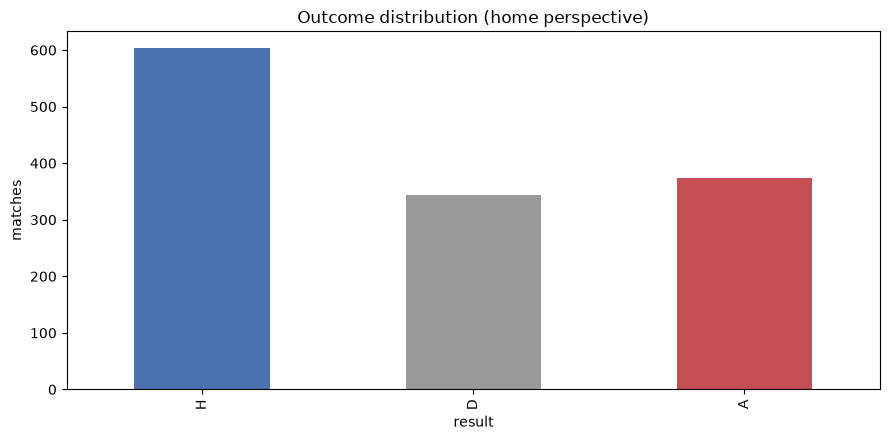

result
H    603
D    344
A    373
Name: count, dtype: int64

In [3]:
tr = build_training_matches(matches, config)
counts = tr['result'].value_counts().reindex(['H', 'D', 'A'])
ax = counts.plot.bar(color=['#4C72B0', '#999999', '#C44E52'])
ax.set_title('Outcome distribution (home perspective)')
ax.set_xlabel('result'); ax.set_ylabel('matches')
plt.tight_layout(); plt.show()
counts

## Goals per match

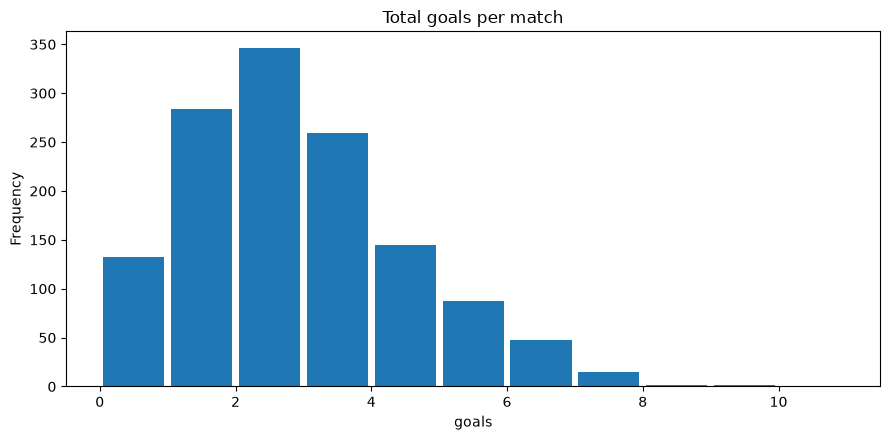

mean goals/match: 2.42


In [4]:
ax = tr['total_goals'].plot.hist(bins=range(0, 12), rwidth=0.9)
ax.set_title('Total goals per match')
ax.set_xlabel('goals'); plt.tight_layout(); plt.show()
print('mean goals/match:', round(tr['total_goals'].mean(), 2))

## Matches played per team and the group draw

In [5]:
display(team_match_counts(matches).head(10).to_frame('matches'))
groups.groupby('group')['team'].apply(list)

,matches
home_team,
Cape Verde,70
Uzbekistan,69
Panama,66
DR Congo,66
Qatar,66
Japan,64
South Africa,64
Netherlands,64
Portugal,63


group
A    [Mexico, South Africa, South Korea, Czech Repu...
B    [Canada, Switzerland, Qatar, Bosnia & Herzegov...
C                   [Brazil, Morocco, Haiti, Scotland]
D                   [USA, Paraguay, Australia, Turkey]
E             [Germany, Curaçao, Ivory Coast, Ecuador]
F                [Netherlands, Japan, Tunisia, Sweden]
G                  [Belgium, Egypt, Iran, New Zealand]
H           [Spain, Cape Verde, Saudi Arabia, Uruguay]
I                      [France, Senegal, Norway, Iraq]
J                [Argentina, Algeria, Austria, Jordan]
K           [Portugal, Uzbekistan, Colombia, DR Congo]
L                    [England, Croatia, Ghana, Panama]
Name: team, dtype: object